# How effectively do different optimizers find high-quality biological sequences?
In the following notebook three different optimizon apporaches are evaluated with the MLP surrogate to answer the question how well are they doing if the surrgate suffers from distributional shift. 


Training Data: 


GB1
Selected 27657 training samples.
Training score range: -10.896890414973896 - -2.7896733393825137


In [2]:
import os
from experiment_runner import ExperimentRunner
import pandas as pd
from assets.plot import plot_trajectory_quality_vs_distance, plot_surrogate_reliability_vs_distance
from assets.plot import plot_trajectory_optimization_progress
import matplotlib.pyplot as plt

/Users/meier/Documents/MasterThesis/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/meier/Documents/MasterThesis/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# Helper function for calculating the maximum oracle score
def calculate_max_oracle_score(df):
    best_per_run = df.loc[df.groupby('run_id')['oracle_score'].idxmax()][['run_id', 'iteration', 'oracle_score', 'method', 'dataset']]
    max_oracle_score = best_per_run['oracle_score'].mean()
    std = best_per_run['oracle_score'].std()

    iteration_mean = best_per_run['iteration'].mean()
    iteration_std = best_per_run['iteration'].std()

    # Print the results in table format
    print(f"Method - Dataset: {best_per_run['method'].iloc[0]} - {best_per_run['dataset'].iloc[0]}")
    print(f"Max Oracle Score: {max_oracle_score:.3f} ± {std:.3f}")
    print(f"Mean Iteration for Max Oracle Score: {iteration_mean:.2f} ± {iteration_std:.2f}")

## Naive Appraoch: Single Mutant Walker and a MLP surrogate

#### TFBind8 

In [9]:
if not os.path.exists('results/trajectory_smw_tfbind8.csv'):
    runner = ExperimentRunner(keyword='smw_tfbind8')
    df = runner.run_and_save()
else: 
    df = pd.read_csv('results/trajectory_smw_tfbind8.csv')

Method - Dataset: smw - tfbind8
Max Oracle Score: 0.859 ± 0.101
Mean Iteration for Max Oracle Score: 6.20 ± 2.74


<Axes: title={'center': 'Surrogate Model Reliability: Correlation vs OOD Distance'}, xlabel='Min Hamming Distance to Training Set', ylabel='Spearman Correlation'>

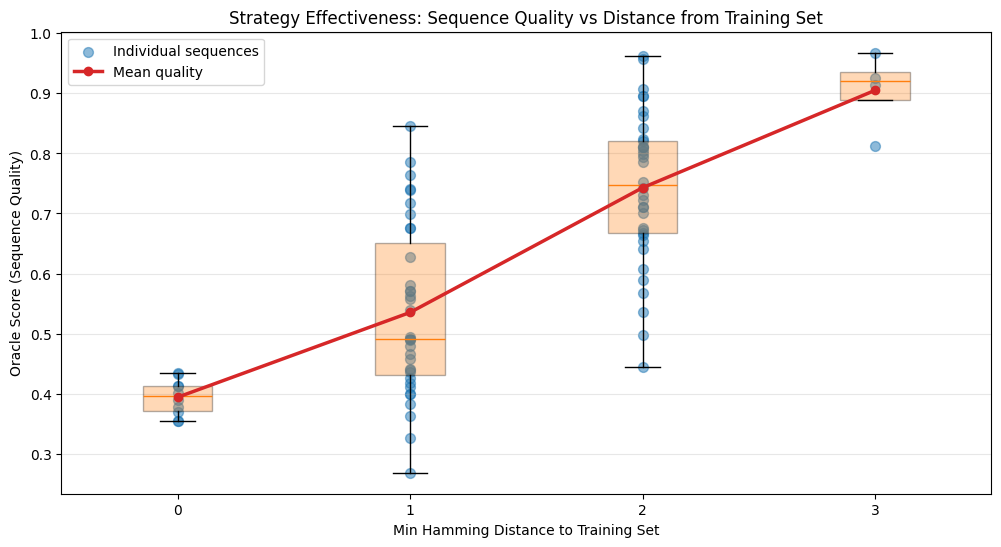

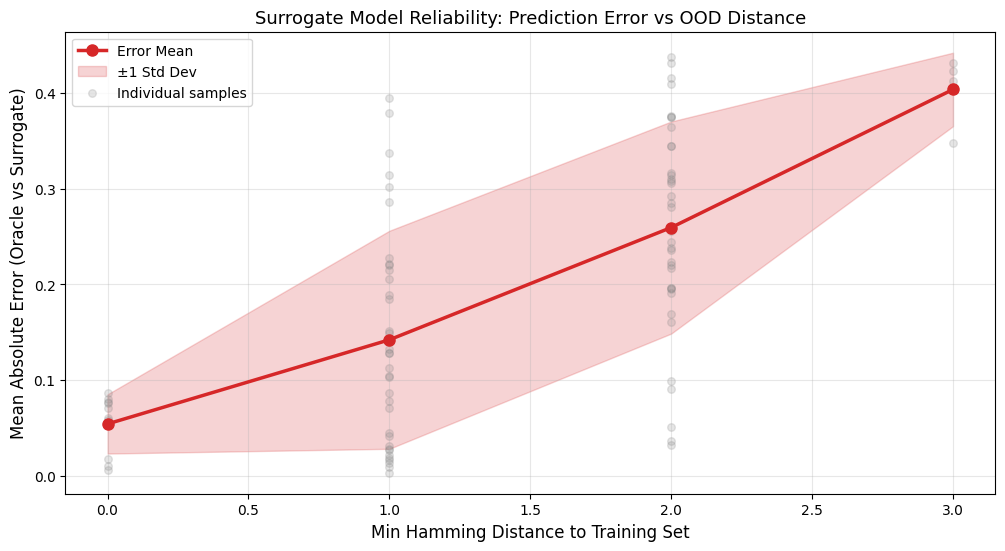

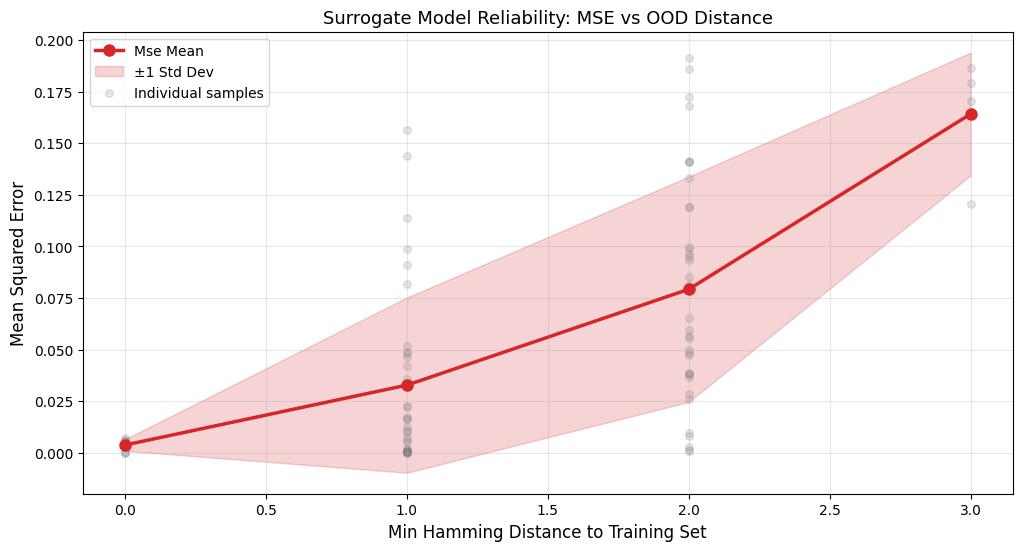

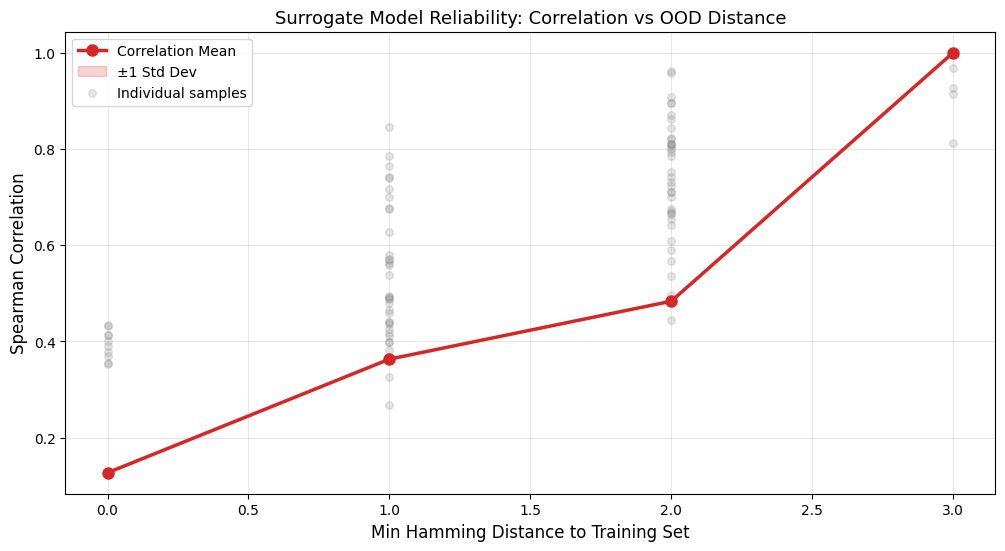

In [10]:
calculate_max_oracle_score(df)

plot_trajectory_quality_vs_distance(df, oracle_col='oracle_score', hamming_col='min_hamming_distance', plot_type='both')

# Absolute error between oracle and surrogate (default)
plot_surrogate_reliability_vs_distance(df, metric='error')

# Mean Squared Error
plot_surrogate_reliability_vs_distance(df, metric='mse')

# Spearman correlation (ranking quality)
plot_surrogate_reliability_vs_distance(df, metric='correlation')

#### GB1

In [11]:
if not os.path.exists('results/trajectory_smw_gb1.csv'):
    experiment_runner = ExperimentRunner(keyword = 'smw_gb1')
    df = experiment_runner.run_and_save(parallel=False)
else:
    df = pd.read_csv('results/trajectory_smw_gb1.csv')

In [12]:
calculate_max_oracle_score(df)

Method - Dataset: smw - gb1
Max Oracle Score: 1.240 ± 0.672
Mean Iteration for Max Oracle Score: 9.70 ± 3.23


<Axes: title={'center': 'Surrogate Model Reliability: Correlation vs OOD Distance'}, xlabel='Min Hamming Distance to Training Set', ylabel='Spearman Correlation'>

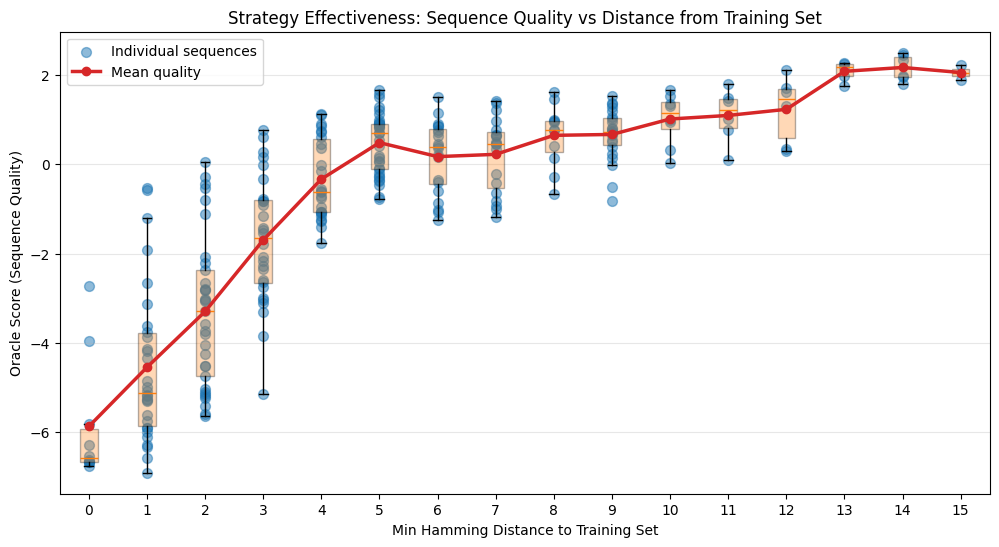

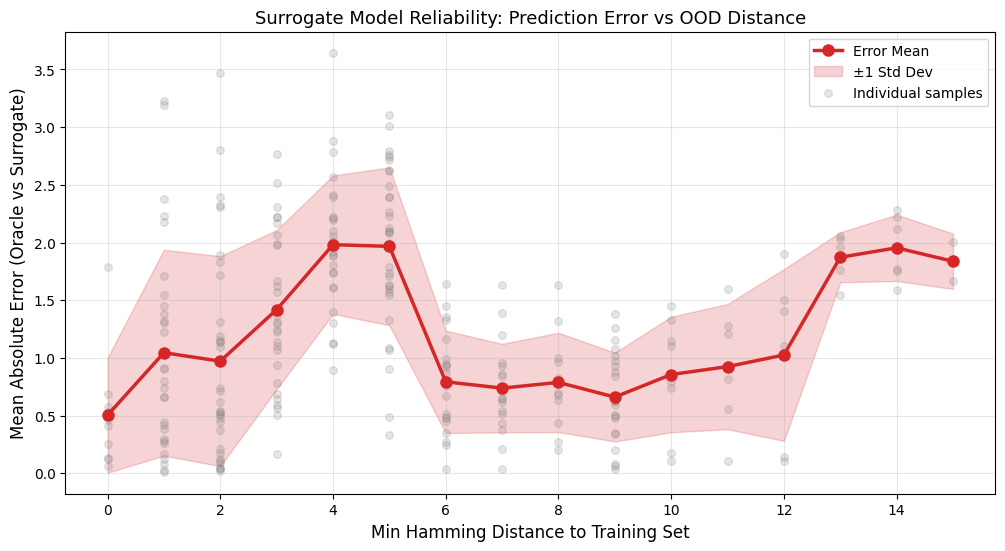

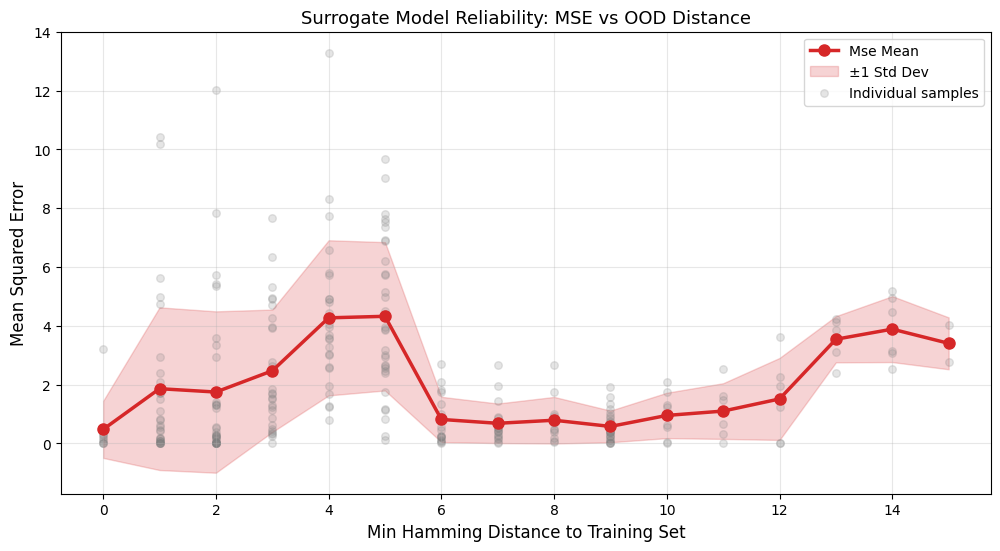

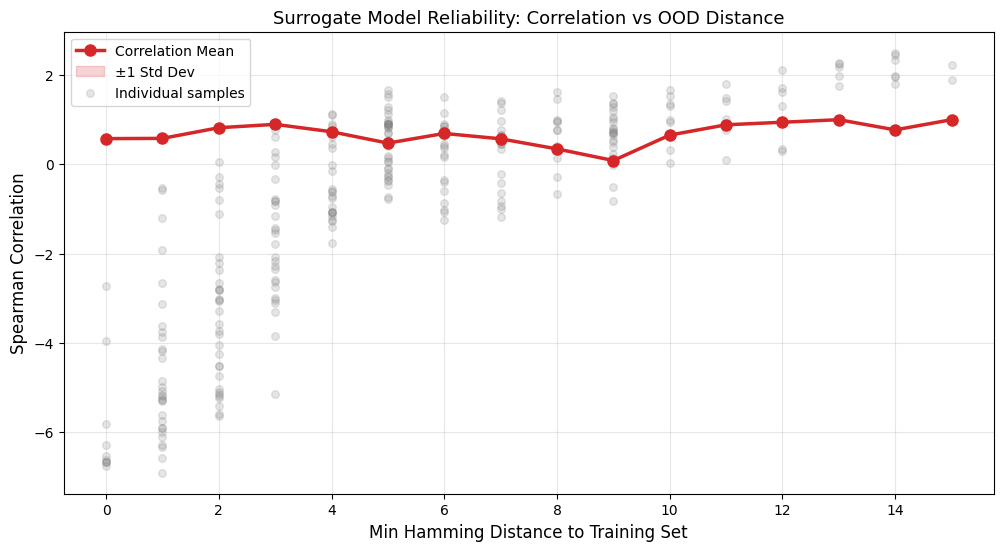

In [13]:
plot_trajectory_quality_vs_distance(df, oracle_col='oracle_score', hamming_col='min_hamming_distance', plot_type='both')

# Absolute error between oracle and surrogate (default)
plot_surrogate_reliability_vs_distance(df, metric='error')

# Mean Squared Error
plot_surrogate_reliability_vs_distance(df, metric='mse')

# Spearman correlation (ranking quality)
plot_surrogate_reliability_vs_distance(df, metric='correlation')

## Reinforcement Appraoch
Scince the naive SMW appraoch is very limited in exploration as the experiments above show, in the following a Reinforcement Learning Approach is used for the same two problems.

In this appraoch the sequences are predicted by a LSTM and scored with a RF. The best 20% of the predicted sequences are then mixed with sequences from the training set and used to retrain the LSTM. 

#### TFBind8

In [4]:
if not os.path.exists('results/trajectory_rl_tfbind8.csv'):
    experiment_runner = ExperimentRunner(keyword='rl_tfbind8')
    df = experiment_runner.run_and_save(parallel=False)
else:
    df = pd.read_csv('results/trajectory_rl_tfbind8.csv')


############################################################
Running experiment: rl_tfbind8
Method: rl
Dataset: tfbind8
Runs: 10
Iterations per run: 15
Parallel: False
############################################################


Run 1/10 - RL
Selected 4105 training samples.
Training score range: 0.0019585206173360348 - 0.439296156167984
Pretraining epoch 0/30, Loss: 1.3246
Pretraining epoch 5/30, Loss: 1.1953
Pretraining epoch 10/30, Loss: 1.1543
Pretraining epoch 15/30, Loss: 1.1311
Pretraining epoch 20/30, Loss: 1.1130
Pretraining epoch 25/30, Loss: 1.0971
RL Iteration 1/15 (temp=0.50)
Pretraining epoch 0/20, Loss: 1.4873
Pretraining epoch 5/20, Loss: 0.9621
Pretraining epoch 10/20, Loss: 0.8073
Pretraining epoch 15/20, Loss: 0.6958
RL Iteration 2/15 (temp=0.54)
Pretraining epoch 0/20, Loss: 1.2081
Pretraining epoch 5/20, Loss: 0.6914
Pretraining epoch 10/20, Loss: 0.4726
Pretraining epoch 15/20, Loss: 0.3509
RL Iteration 3/15 (temp=0.57)
Pretraining epoch 0/20, Loss: 0.5144
Pretr

In [5]:
#print number of total found sequences per run
print(f"Number of unique sequences found per run: {df.groupby('run_id').size()}")

df.groupby('run_id')['sequence'].apply(lambda x: x.nunique())

Number of unique sequences found per run: run_id
1     33
2     49
3     39
4     44
5     26
6     62
7     68
8     57
9     51
10    60
dtype: int64


run_id
1     25
2     38
3     32
4     42
5     14
6     53
7     59
8     55
9     46
10    51
Name: sequence, dtype: int64

In [6]:
calculate_max_oracle_score(df)

Method - Dataset: rl - tfbind8
Max Oracle Score: 0.888 ± 0.092
Mean Iteration for Max Oracle Score: 4.00 ± 2.94


<Axes: title={'center': 'Surrogate Model Reliability: Correlation vs OOD Distance'}, xlabel='Min Hamming Distance to Training Set', ylabel='Spearman Correlation'>

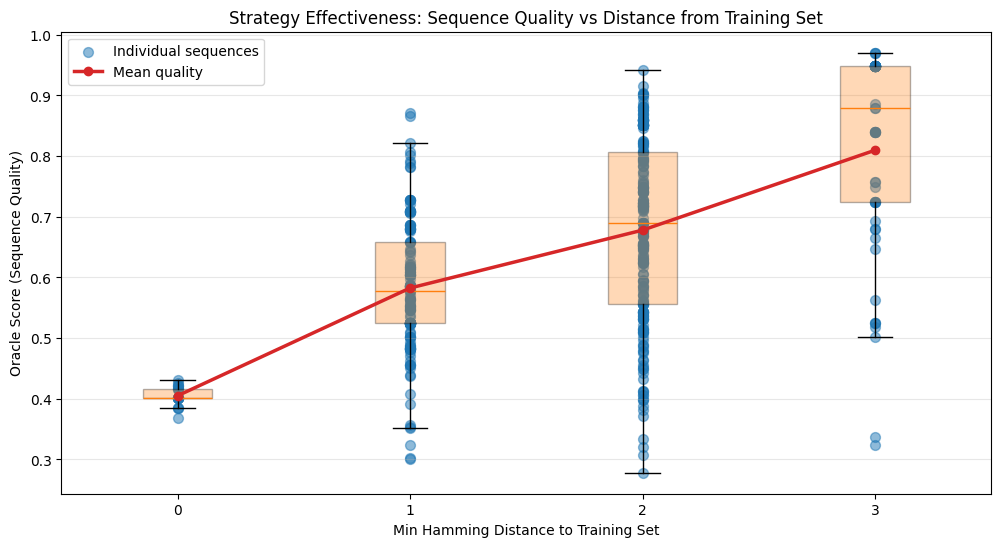

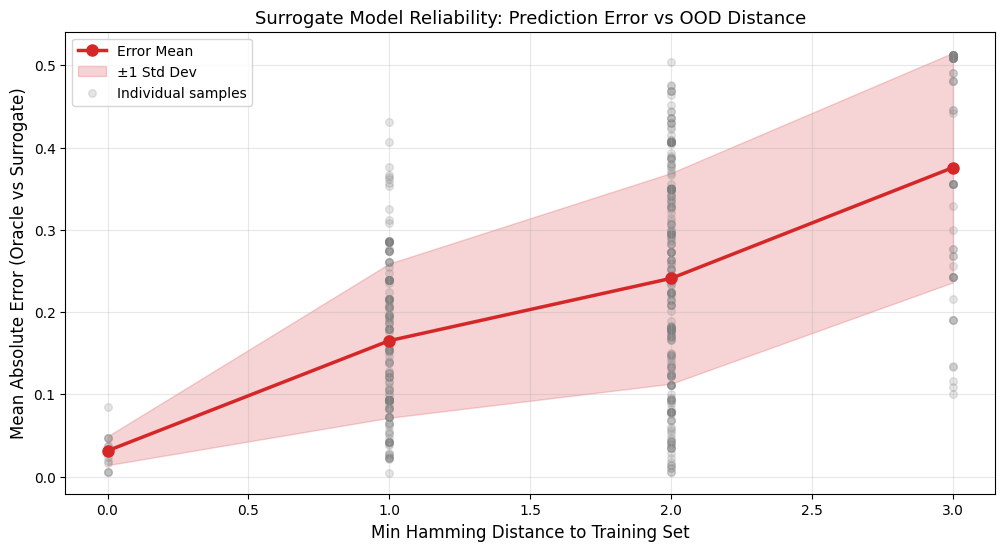

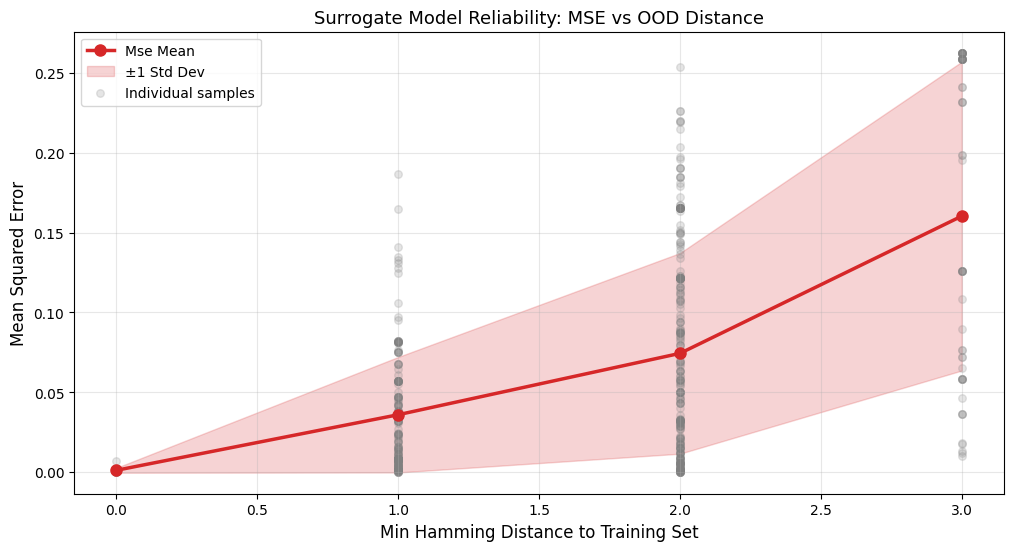

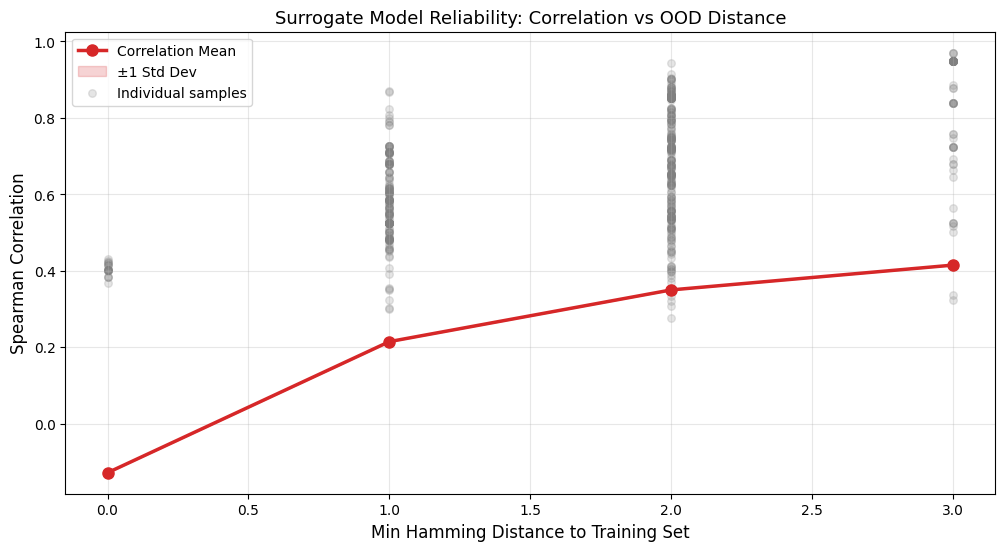

In [7]:
plot_trajectory_quality_vs_distance(df, oracle_col='oracle_score', hamming_col='min_hamming_distance', plot_type='both')

# Absolute error between oracle and surrogate (default)
plot_surrogate_reliability_vs_distance(df, metric='error')

# Mean Squared Error
plot_surrogate_reliability_vs_distance(df, metric='mse')

# Spearman correlation (ranking quality)
plot_surrogate_reliability_vs_distance(df, metric='correlation')

The optimization progress is only plotted for one single run

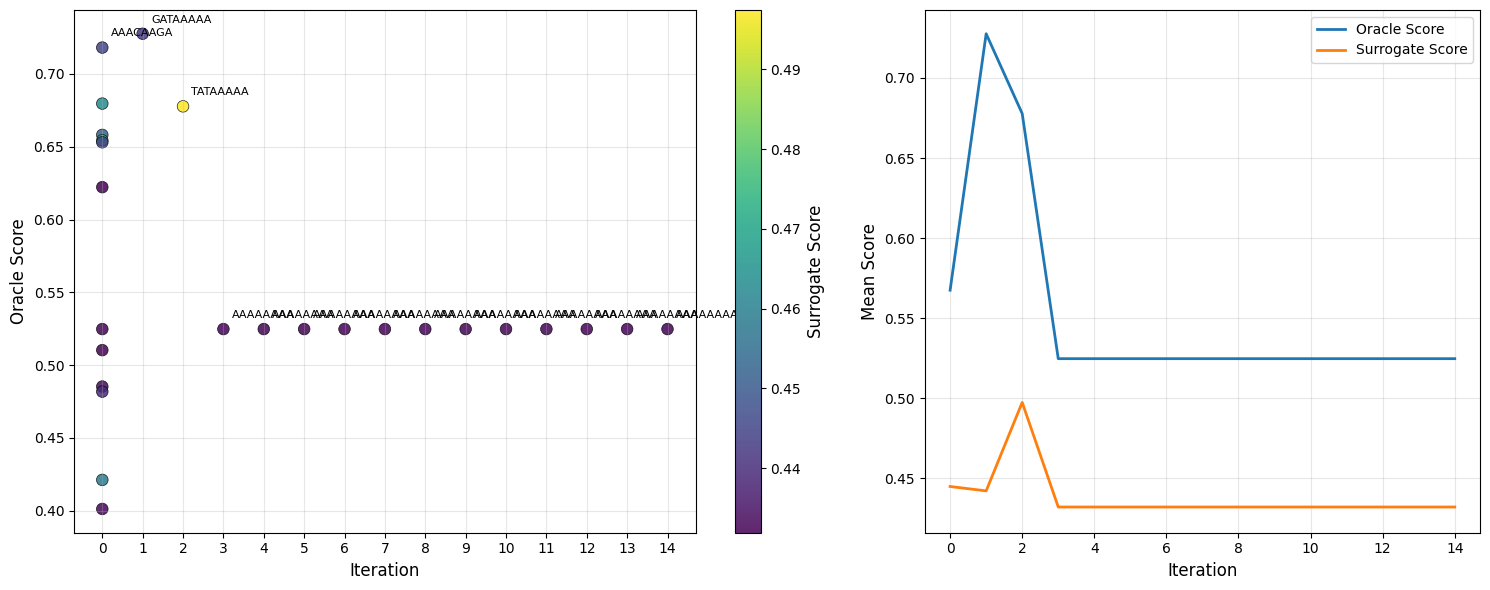

In [11]:
# Plot optimization progress for run 1
fig, axes = plot_trajectory_optimization_progress(df, run_id=5)
plt.show()

#### GB1

In [3]:
if os.path.exists('results/trajectory_rl_gb1.csv'):
    df = pd.read_csv('results/trajectory_rl_gb1.csv')
else:
    experiment_runner = ExperimentRunner(keyword='rl_gb1')
    df = experiment_runner.run_and_save(parallel=False)


############################################################
Running experiment: rl_gb1
Method: rl
Dataset: gb1
Runs: 3
Iterations per run: 5
Parallel: False
############################################################


Run 1/3 - RL
after set_seed:    6275163177290169690
rng 1: 6275163177290169690
Selected 27657 training samples.
Training score range: -10.896890414973896 - -2.7896733393825137
rng 2: 6275163177290169690
rng 3: 6275163177290169690
rng 4: 6275163177290169690
after _setup_gb1:  6275163177290169690
Pretraining epoch 0/5, Loss: 0.3885
RL Iteration 1/5 (temp=0.50)
Pretraining epoch 0/20, Loss: 0.4858
Pretraining epoch 5/20, Loss: 0.3231
Pretraining epoch 10/20, Loss: 0.2784
Pretraining epoch 15/20, Loss: 0.2574
iter=0 seed=43 max_score=0.0848 rng_hash=7238028897402611380
RL Iteration 2/5 (temp=0.62)
Pretraining epoch 0/20, Loss: 0.2435
Pretraining epoch 5/20, Loss: 0.1746
Pretraining epoch 10/20, Loss: 0.1540
Pretraining epoch 15/20, Loss: 0.1344
iter=1 seed=43 max_score=0.

Method - Dataset: rl - gb1
Max Oracle Score: 3.757 ± 1.158
Mean Iteration for Max Oracle Score: 2.33 ± 1.15


<Axes: title={'center': 'Surrogate Model Reliability: Correlation vs OOD Distance'}, xlabel='Min Hamming Distance to Training Set', ylabel='Spearman Correlation'>

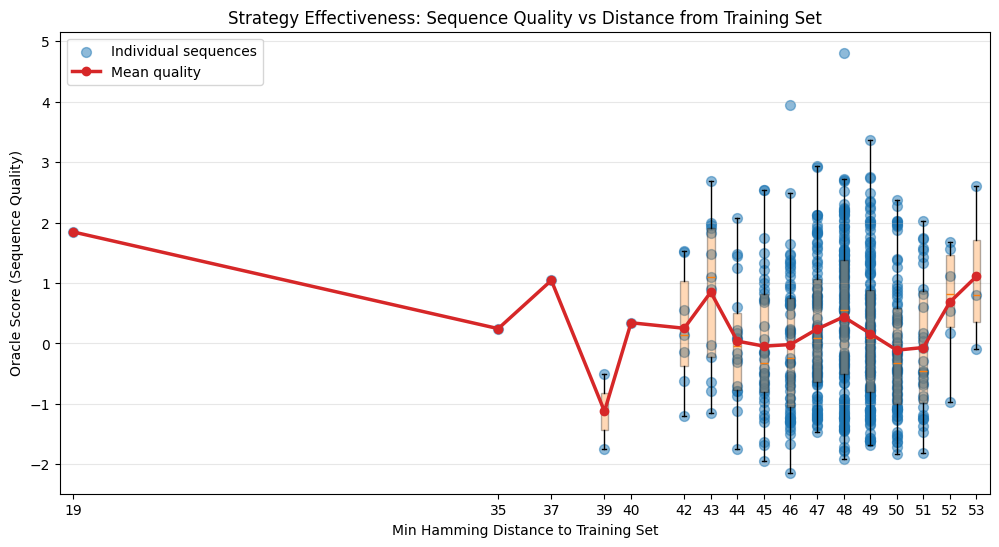

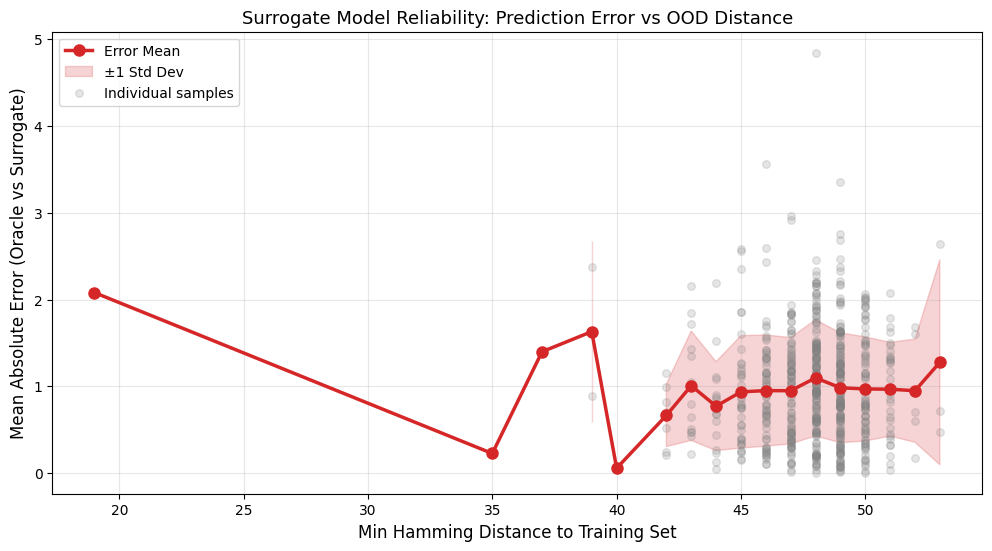

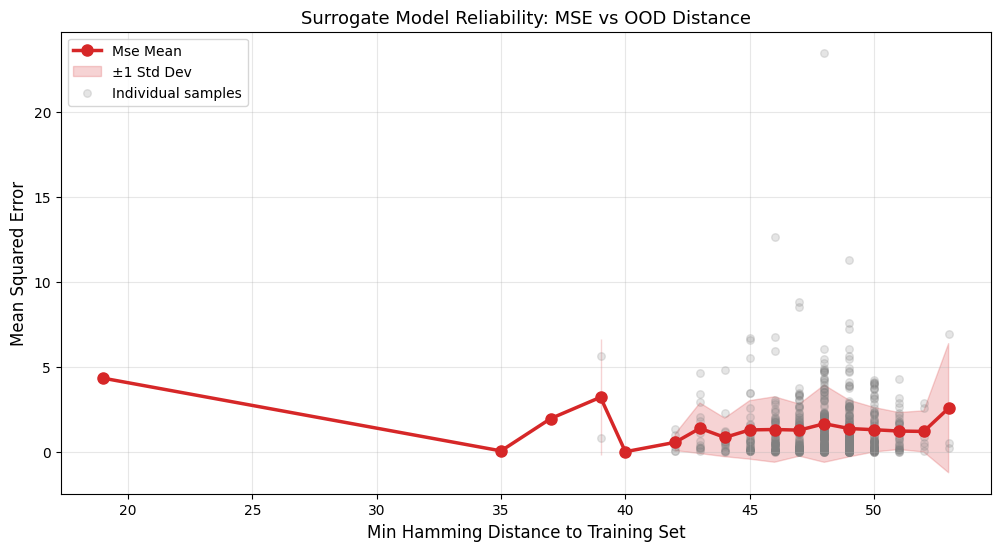

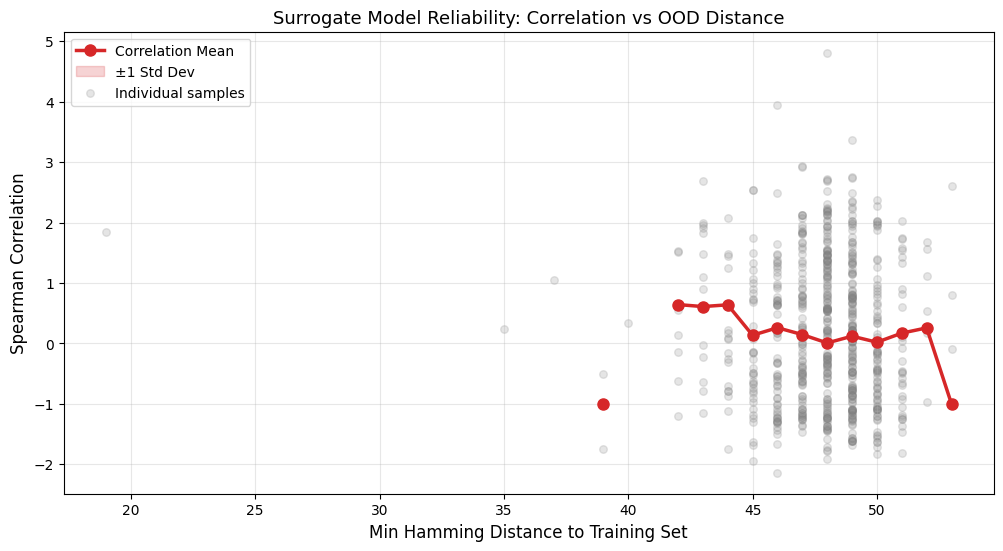

In [6]:
calculate_max_oracle_score(df)

plot_trajectory_quality_vs_distance(df, oracle_col='oracle_score', hamming_col='min_hamming_distance', plot_type='both')

# Absolute error between oracle and surrogate (default)
plot_surrogate_reliability_vs_distance(df, metric='error')

# Mean Squared Error
plot_surrogate_reliability_vs_distance(df, metric='mse')

# Spearman correlation (ranking quality)
plot_surrogate_reliability_vs_distance(df, metric='correlation')


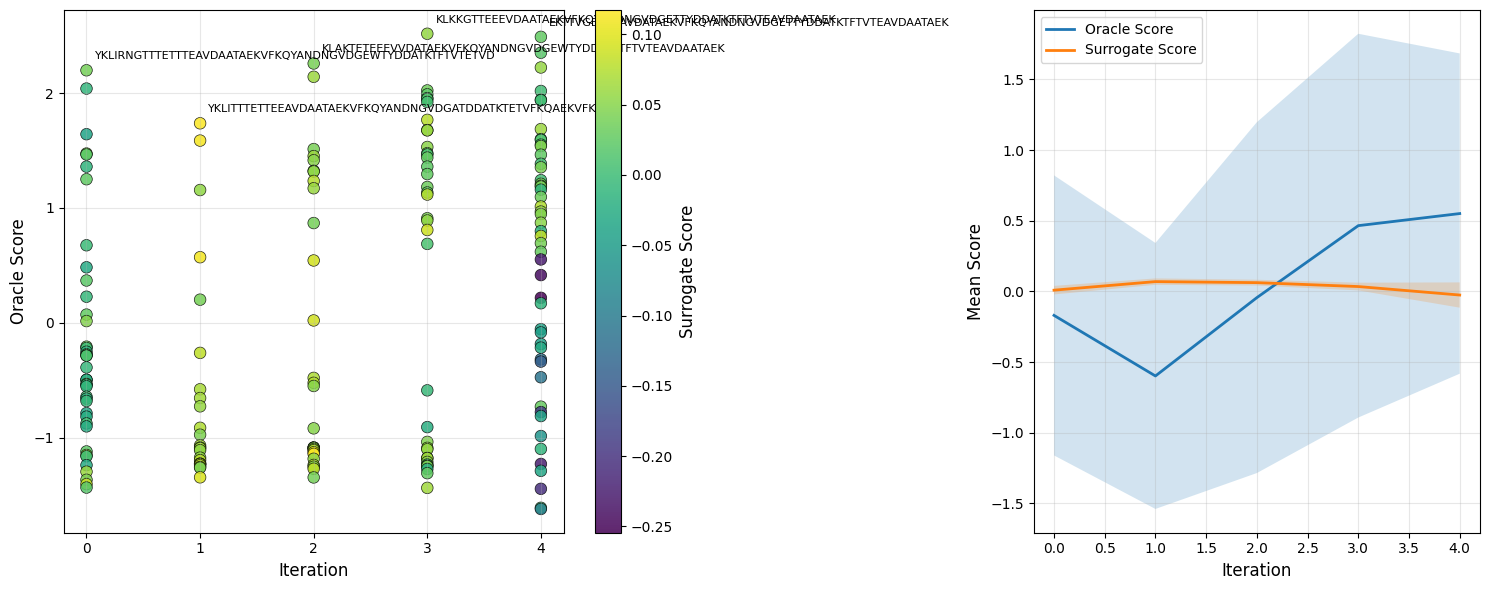

In [7]:
# Plot optimization progress for run 1
fig, axes = plot_trajectory_optimization_progress(df, run_id=1)
plt.show()

#### Investigation about std= 0
The ±0.00 std at the max oracle score means every run finds exaclty the same sequence.
- the runs use differeent seeds? Yes they do
- are generated sequences always identical? Yes
- is the maximum always found in the same iterations? Yes

Cause could be greedy decoding or temperature = 0 -> deterministic regardles of the seed. 
=> no, I can answer all Questions with now at the TFbind8 data

Possible reason: Mode collapse via surrogate exploitation
- MLP is quite good at GB1 data -> RQ1, other notebook => seems not to be the reason.

The score range of GB1 data is -11.2 - 3.6. The Oracle is trained on this data, so a score of 9.32 is far above the training data.
=> Oracle cant be trusted as reliable training data.
The RL escapes the reliable region of the oracle and this makes the evaluation unreliable. 

Now back to The mode collapse:

The mechanism is clear now:

1. The GB1 surrogate has one dominant exploit region it scores extremely high
2. RL fine-tuning pushes the policy so hard toward that region that it loses all entropy
3. By iteration 4, the policy is fully collapsed — deterministic regardless of seed
4. The oracle then also extrapolates beyond its training range for these sequences, giving 9.32


This is actually a textbook example of reward hacking via mode collapse in RL-guided biological sequence design. The finding is solid and well-evidenced. For your thesis I'd structure it as:

- Evidence 1: std = 0.00 across 10 runs
- Evidence 2: identical 765 sequences in every run
- Evidence 3: max always found at iteration 4
- Evidence 4: oracle score 9.32 exceeds the full dataset maximum of 3.60
Conclusion: the RL policy collapsed to a single exploit of the surrogate, and the oracle itself cannot be trusted for these sequences as they lie outside its training distribution

Problem is also the max_score in rl_experiment.py:
It sets the goal_score of the LSTM to 7.6 in the first iteration which is pretty high. 

After long claude discussion: 
More likely the real culprit: the GB1 pretraining dataset is so large and the LSTM so small (128 hidden units) that it converges to essentially the same weights regardless of seed — the model capacity is the bottleneck, not the randomness. All 10 runs end up with virtually identical pretrained LSTMs, then identical fine-tuning, then identical generation.

This is a model capacity / dataset size issue rather than a seeding bug. The finding stands as-is — it's genuinely deterministic behavior caused by the LSTM being too small relative to GB1's complexity, making it insensitive to initialization differences. Worth noting in your thesis as a limitation.

In [8]:
#get the maximum oracle score of the first iteration in run one
df.loc[(df['run_id'] == 1) & (df['iteration'] == 1), 'oracle_score'].max()


1.7371848821640015

In [9]:
df.groupby('run_id').apply(
    lambda g: g[['sequence', 'iteration', 'oracle_score']]
              .sort_values(['iteration', 'sequence'])
              .reset_index(drop=True)
              .equals(
                  df[df['run_id'] == 1][['sequence', 'iteration', 'oracle_score']]
                  .sort_values(['iteration', 'sequence'])
                  .reset_index(drop=True)
              )
)


/var/folders/_2/6p52z75d21dc91tc6ss7n6w80000gn/T/ipykernel_16146/478892033.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby('run_id').apply(


run_id
1     True
2    False
3    False
dtype: bool

In [10]:
# Get sequences per run as a set and compare all to run 1
seqs_per_run = df.groupby('run_id')['sequence'].apply(set)
reference = seqs_per_run.iloc[0]
seqs_per_run.apply(lambda s: s == reference)

run_id
1     True
2    False
3    False
Name: sequence, dtype: bool

## GFlow Net Experiments

In [41]:
if not os.path.exists('results/trajectory_gfn_tfbind8.csv'):
    runner = ExperimentRunner(keyword='gfn_tfbind8')
    df = runner.run_and_save(parallel=False)
else:
    df = pd.read_csv('results/trajectory_gfn_tfbind8.csv')

Method - Dataset: rl - gb1
Max Oracle Score: 3.797 ± 0.000
Mean Iteration for Max Oracle Score: 7.00 ± 0.00


/Users/meier/Documents/MasterThesis/assets/plot.py:419: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr = spearmanr(subset[oracle_col], subset[surrogate_col]).correlation


<Axes: title={'center': 'Surrogate Model Reliability: Correlation vs OOD Distance'}, xlabel='Min Hamming Distance to Training Set', ylabel='Spearman Correlation'>

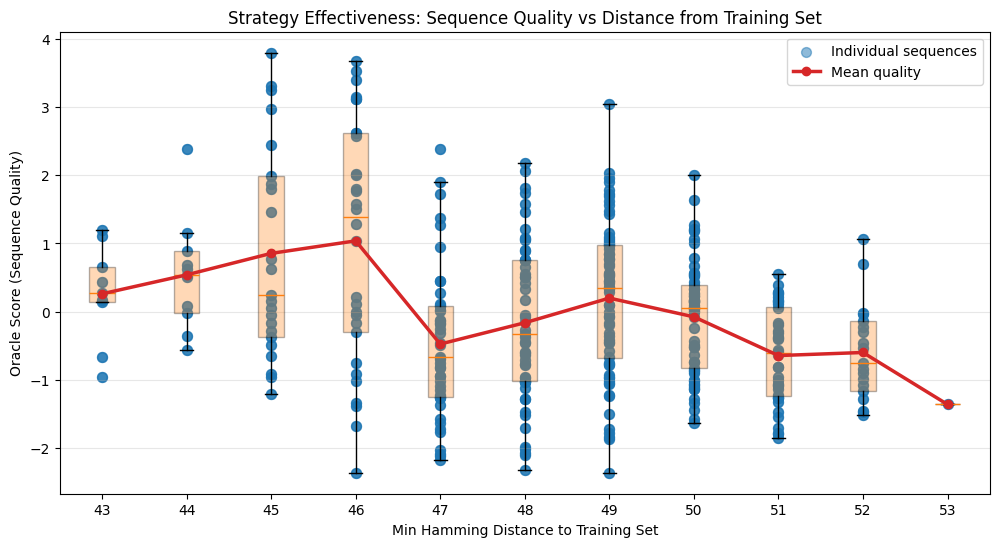

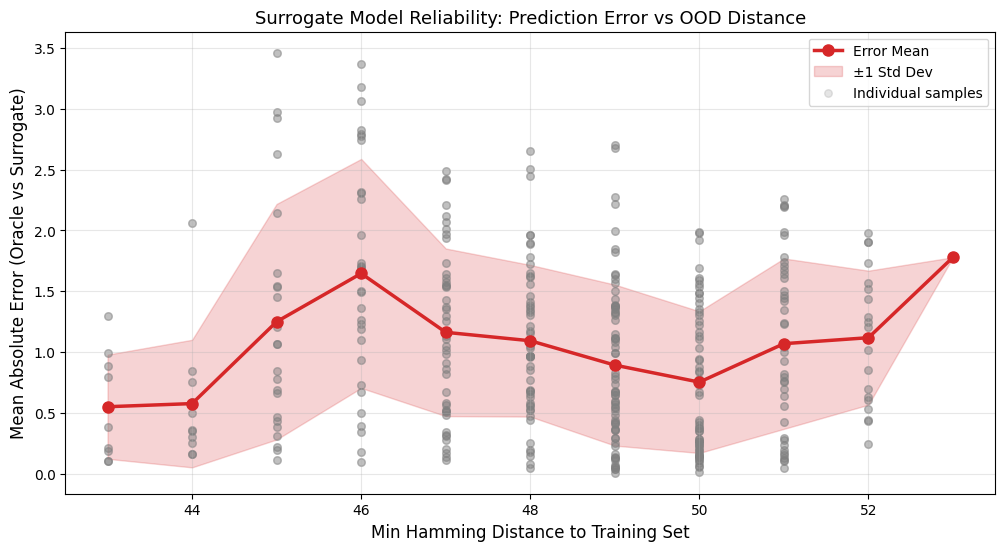

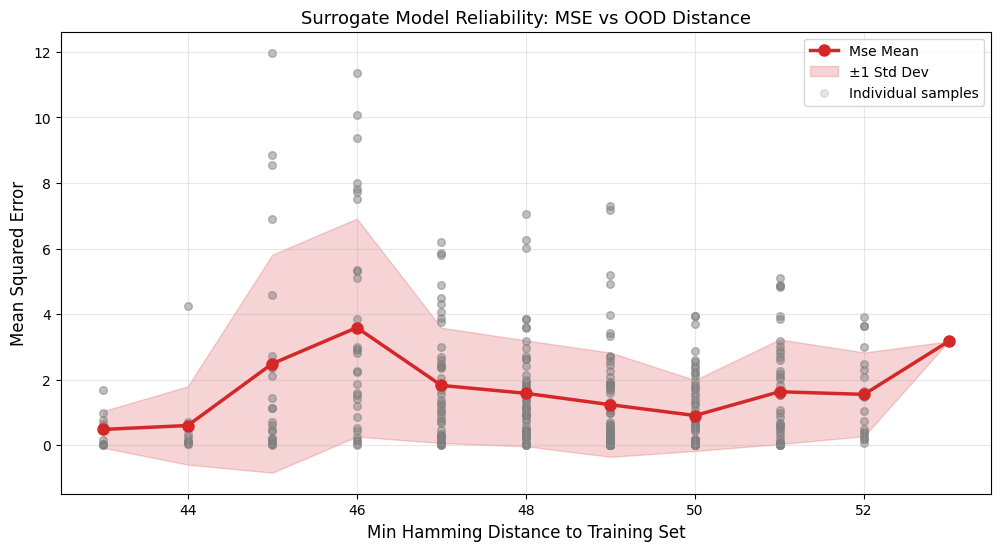

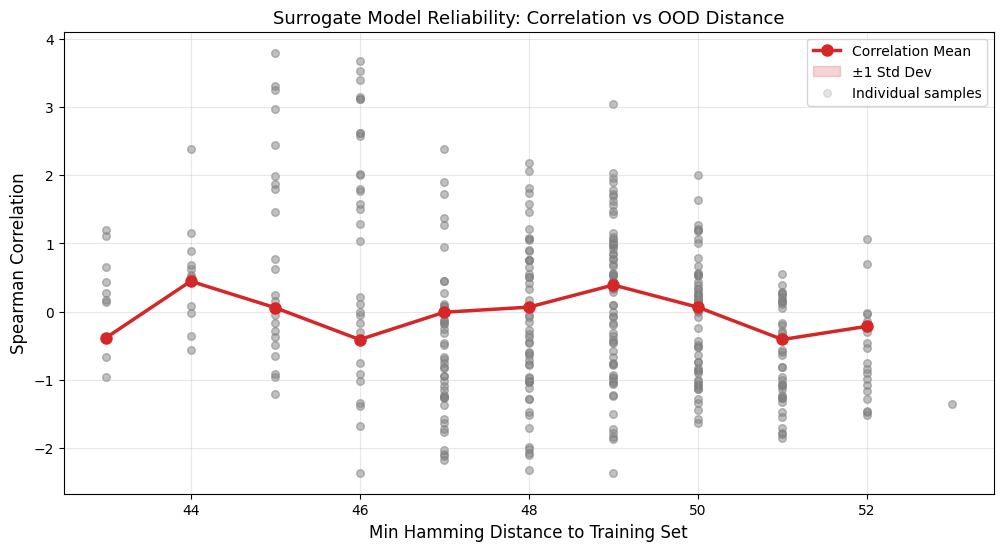

In [5]:
calculate_max_oracle_score(df)

plot_trajectory_quality_vs_distance(df, oracle_col='oracle_score', hamming_col='min_hamming_distance', plot_type='both')

# Absolute error between oracle and surrogate (default)
plot_surrogate_reliability_vs_distance(df, metric='error')

# Mean Squared Error
plot_surrogate_reliability_vs_distance(df, metric='mse')

# Spearman correlation (ranking quality)
plot_surrogate_reliability_vs_distance(df, metric='correlation')



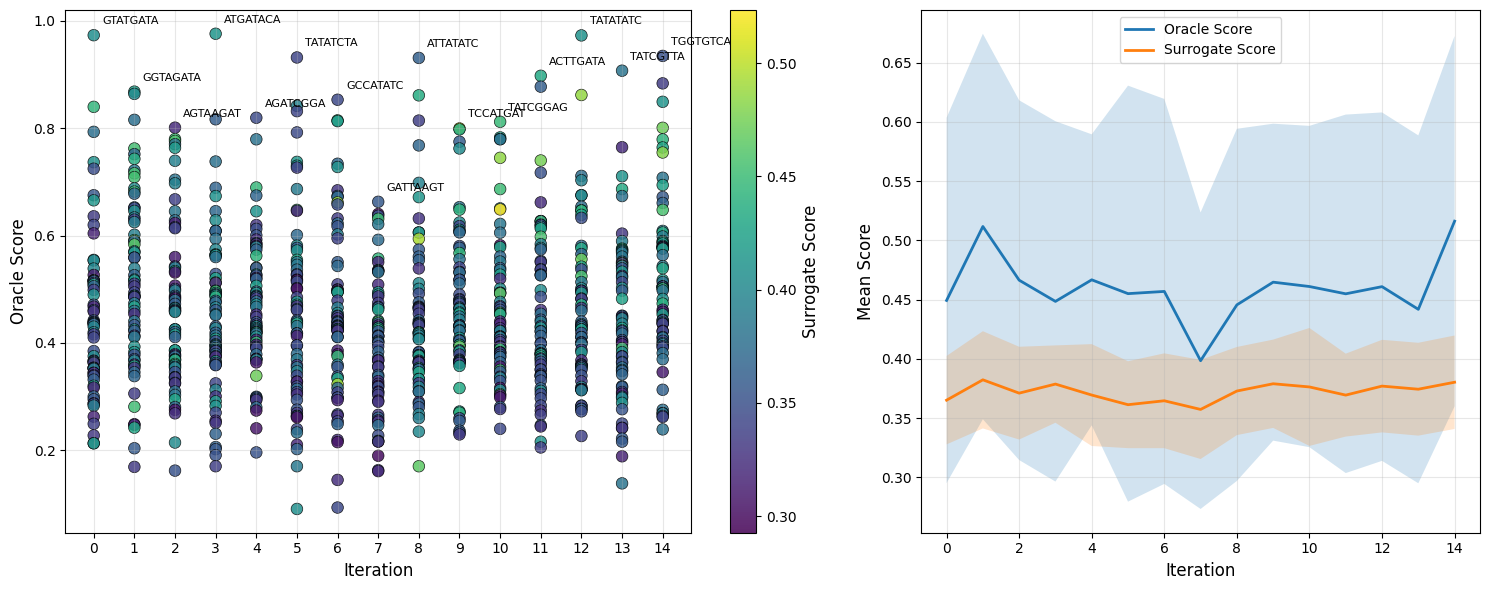

In [6]:
# Plot optimization progress for run 1
fig, axes = plot_trajectory_optimization_progress(df, run_id=1)
plt.show()

#### GB1

Still just one run

In [43]:
if not os.path.exists('results/trajectory_gfn_gb1.csv'):
    runner = ExperimentRunner(keyword='gfn_gb1')
    df = runner.run_and_save(parallel=False)
else:
    df = pd.read_csv('results/trajectory_gfn_gb1.csv')

Summary:
13522.8s	744	  Runs: 1
13522.8s	745	  Iterations per run: 14.0
13522.8s	746	  Avg records per run: 3840.0
13522.8s	747	
13522.8s	748	Oracle scores:
13522.8s	749	  Min: -3.3838
13522.8s	750	  Max: 8.2092
13522.8s	751	  Mean: 0.5051
13522.8s	752	
13522.8s	753	Hamming distances:
13522.8s	754	  Min: 33
13522.8s	755	  Max: 53.0
13522.8s	756	  Mean: 49.5
13522.8s	757	Total time: 13429.3 seconds (223.8 minutes)
13528.5s	758	Experiment finished.

Method - Dataset: gfn - gb1
Max Oracle Score: 8.209 ± nan
Mean Iteration for Max Oracle Score: 5.00 ± nan


<Axes: title={'center': 'Surrogate Model Reliability: Correlation vs OOD Distance'}, xlabel='Min Hamming Distance to Training Set', ylabel='Spearman Correlation'>

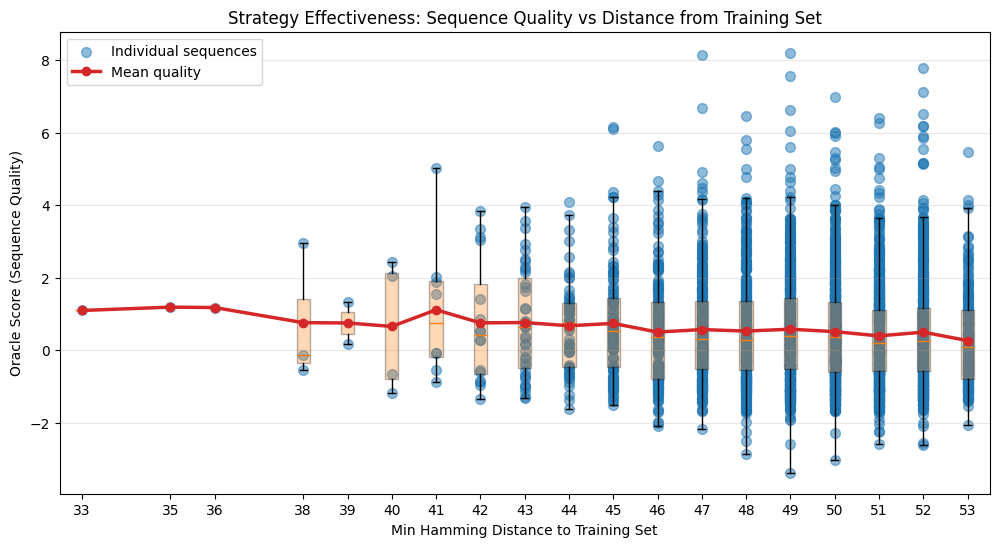

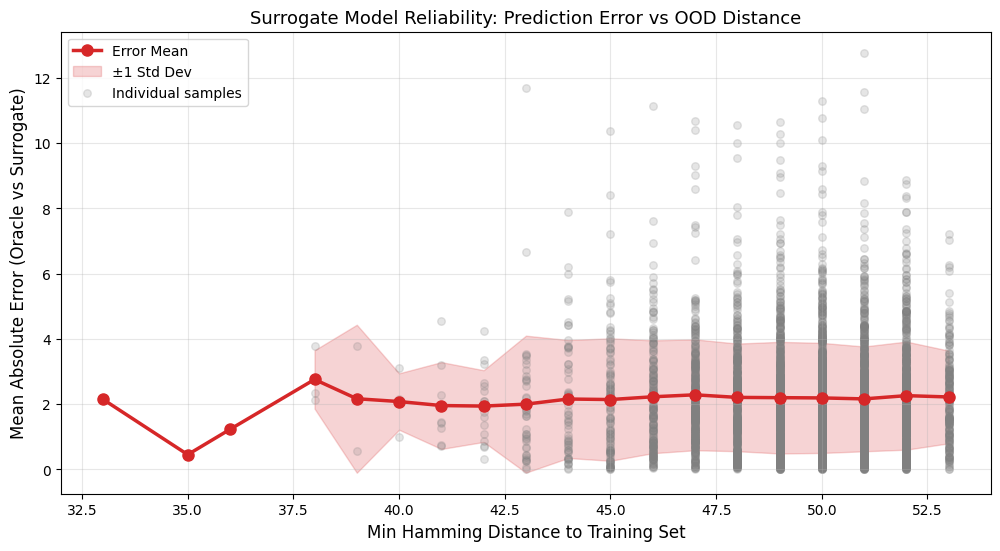

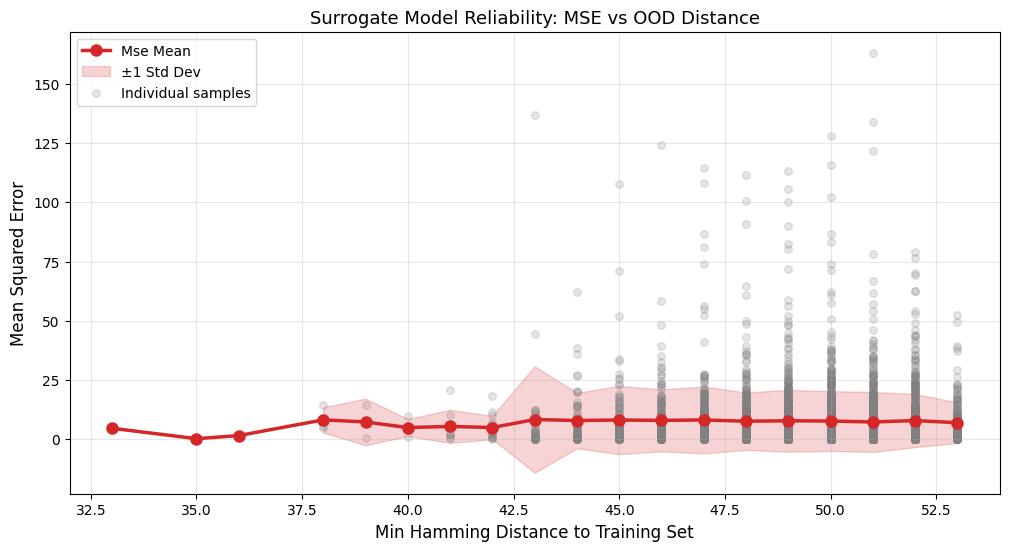

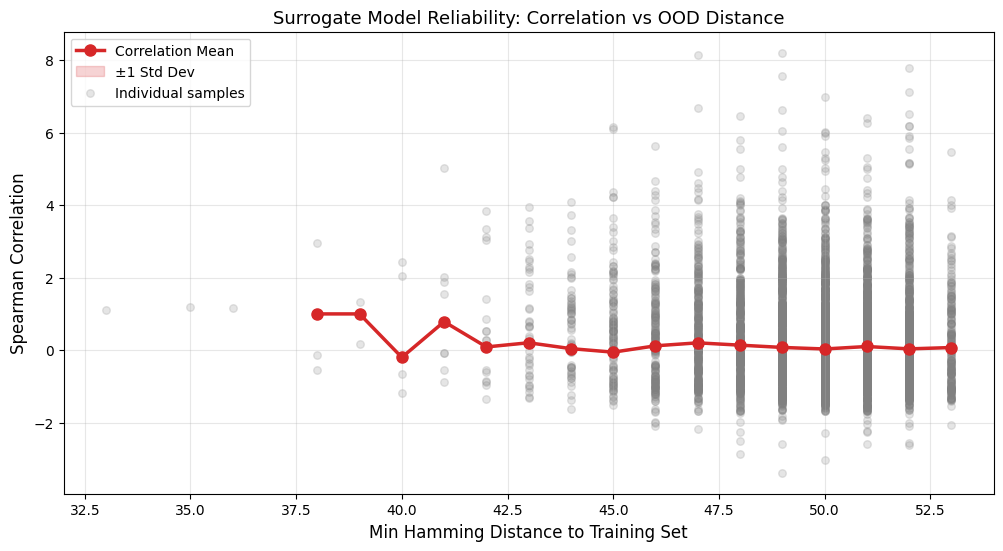

In [44]:
calculate_max_oracle_score(df)

plot_trajectory_quality_vs_distance(df, oracle_col='oracle_score', hamming_col='min_hamming_distance', plot_type='both')

# Absolute error between oracle and surrogate (default)
plot_surrogate_reliability_vs_distance(df, metric='error')

# Mean Squared Error
plot_surrogate_reliability_vs_distance(df, metric='mse')

# Spearman correlation (ranking quality)
plot_surrogate_reliability_vs_distance(df, metric='correlation')

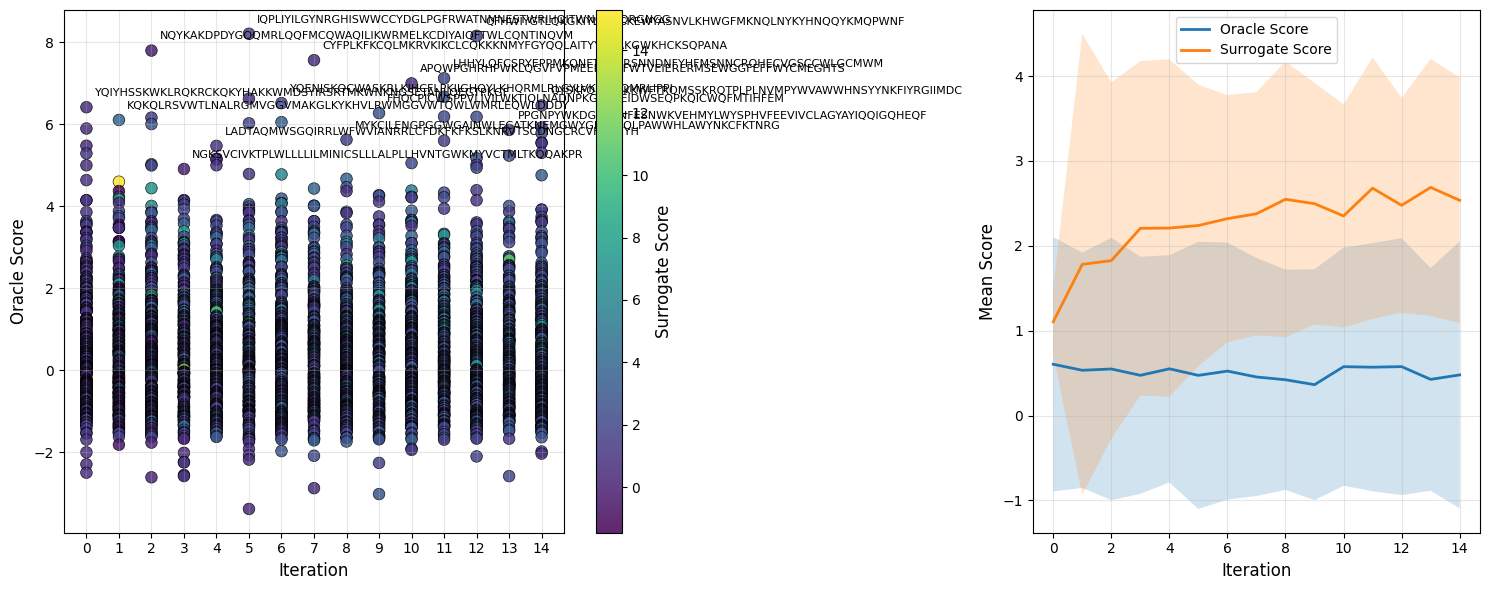

In [21]:
# Plot optimization progress for run 1
fig, axes = plot_trajectory_optimization_progress(df, run_id=1)
plt.show()

## Comparison of all the models

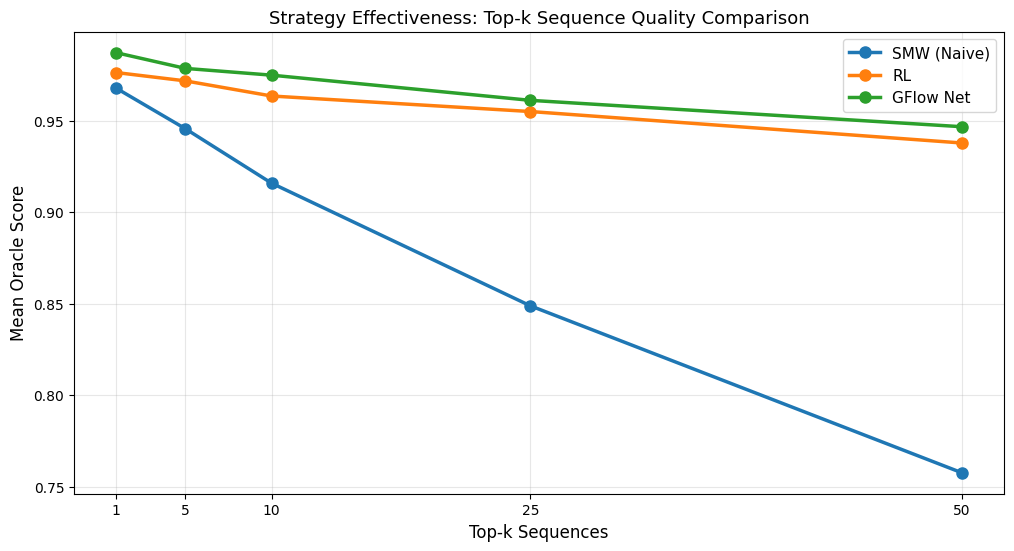

In [45]:
from assets.plot import plot_strategy_comparison_topk
import pandas as pd

# Load trajectory data from each strategy
df_smw = pd.read_csv('results/trajectory_smw_tfbind8.csv')
df_rl = pd.read_csv('results/trajectory_rl_tfbind8.csv')
df_gfn = pd.read_csv('results/trajectory_gfn_tfbind8.csv')

# Compare strategies
plot_strategy_comparison_topk({
    'SMW (Naive)': df_smw,
    'RL': df_rl,
    'GFlow Net': df_gfn
})

plt.show()

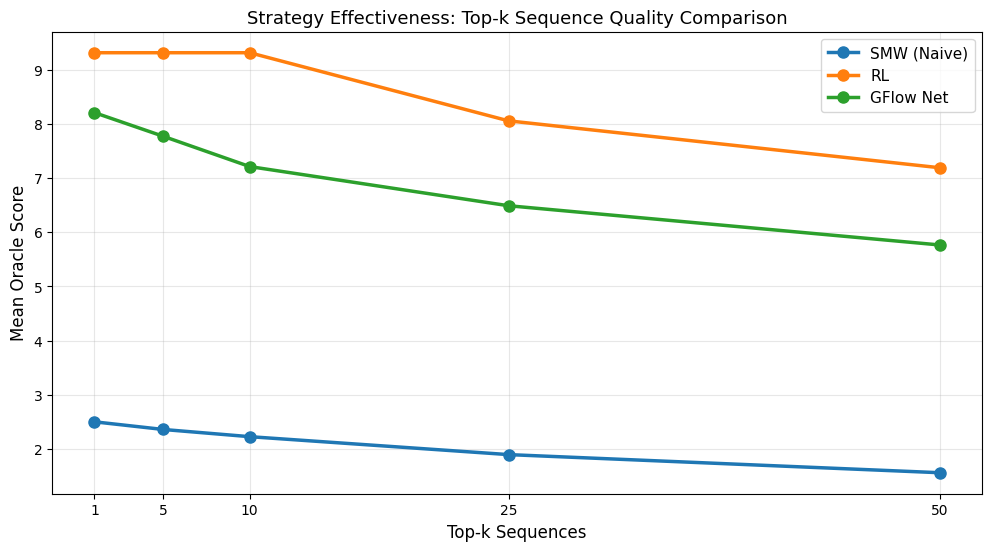

In [46]:
# Load trajectory data from each strategy
df_smw = pd.read_csv('results/trajectory_smw_gb1.csv')
df_rl = pd.read_csv('results/trajectory_rl_gb1.csv')
df_gfn = pd.read_csv('results/trajectory_gfn_gb1.csv')

# Compare strategies
plot_strategy_comparison_topk({
    'SMW (Naive)': df_smw,
    'RL': df_rl,
    'GFlow Net': df_gfn
})

plt.show()

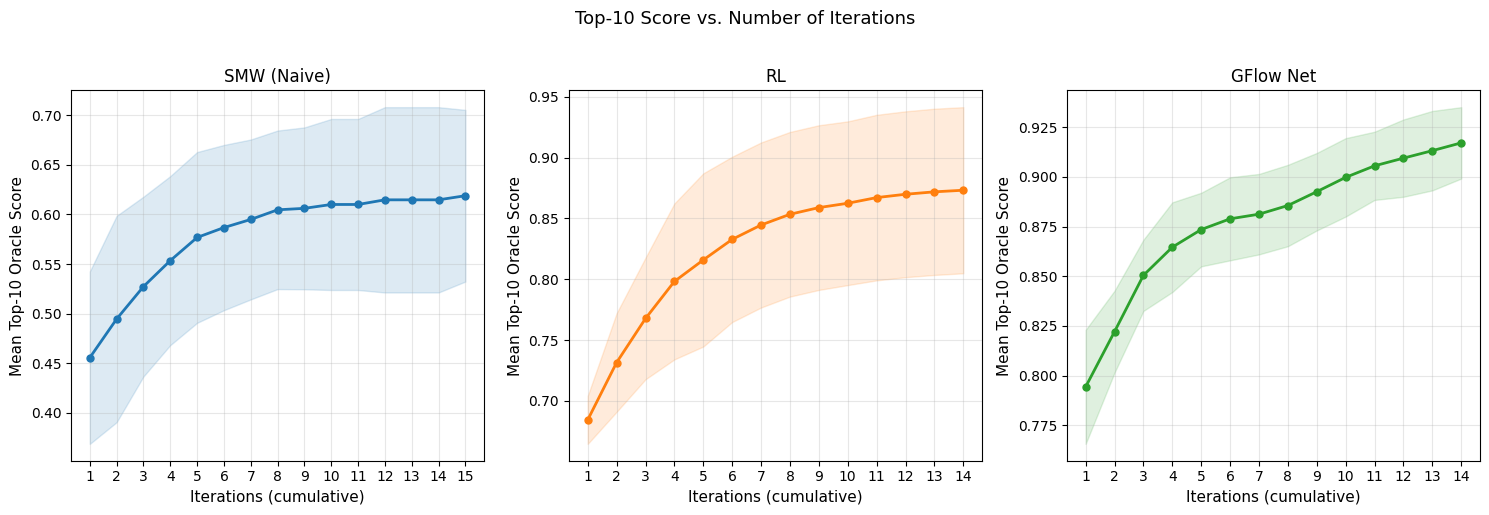

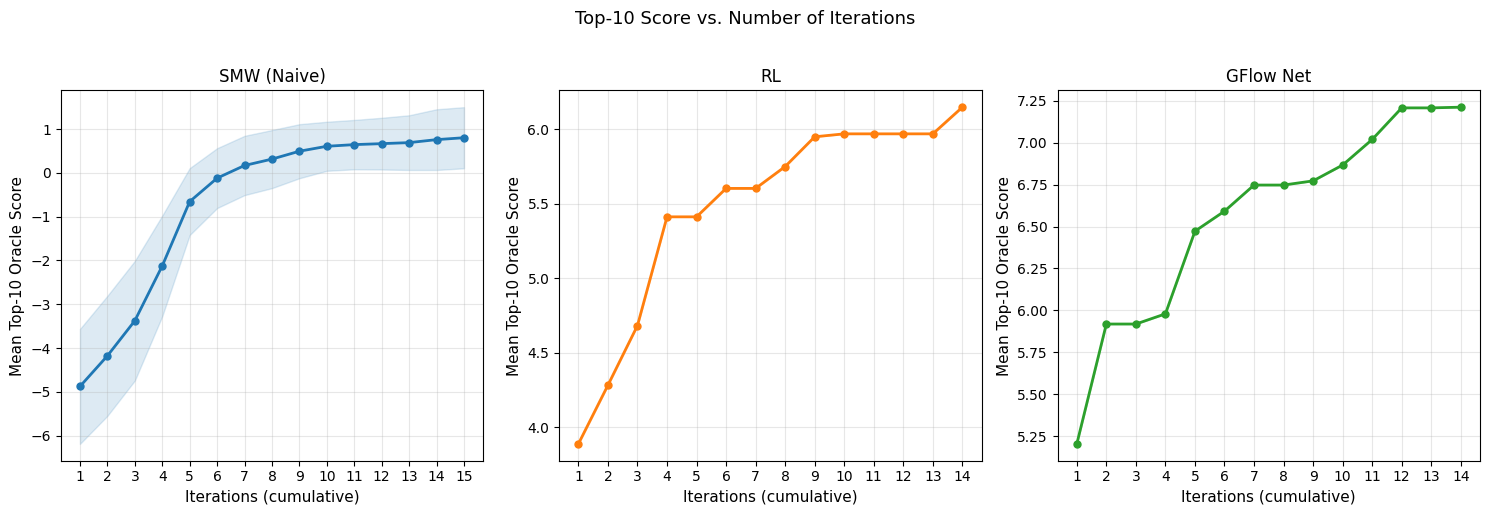

In [47]:
from assets.plot import plot_topk_over_iterations

df_smw = pd.read_csv('results/trajectory_smw_tfbind8.csv')
df_rl  = pd.read_csv('results/trajectory_rl_tfbind8.csv')
df_gfn = pd.read_csv('results/trajectory_gfn_tfbind8.csv')

plot_topk_over_iterations(
    {'SMW (Naive)': df_smw, 'RL': df_rl, 'GFlow Net': df_gfn},
    k=10
)
plt.show()

df_smw = pd.read_csv('results/trajectory_smw_gb1.csv')
df_rl  = pd.read_csv('results/trajectory_rl_gb1.csv')
df_gfn = pd.read_csv('results/trajectory_gfn_gb1.csv')
plot_topk_over_iterations(
    {'SMW (Naive)': df_smw, 'RL': df_rl, 'GFlow Net': df_gfn},
    k=10
)
plt.show()

##### Missing std shadows:
1. RL at GB1 (lower, middle):
see investigation at section GB1
2. GFlow Net approaches:
As GFlowNet runs quite a while, just one test was run so far. 

In [48]:
# print score ranges of dataframe
print(f"SMW (Naive) score range: {df_smw['oracle_score'].min():.4f} - {df_smw['oracle_score'].max():.4f}")
print(f"RL score range: {df_rl['oracle_score'].min():.4f} - {df_rl['oracle_score'].max():.4f}")
print(f"GFlow Net score range: {df_gfn['oracle_score'].min():.4f} - {df_gfn['oracle_score'].max():.4f}")

SMW (Naive) score range: -6.9057 - 2.4994
RL score range: -4.3788 - 9.3154
GFlow Net score range: -3.3838 - 8.2092
